# Tugas Besar 1 Pembelajaran Mesin

13523003 Dave Daniell Yanni

13523036 Yonatan Edward Njoto

## 1. Import Library

Mengimpor dependensi eksternal (pandas, numpy, matplotlib, scikit-learn) dan modul internal (`NeuralNetwork` dari package `core`).

In [37]:
# external lib imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neural_network import MLPClassifier


SEED_VALUE = 36
np.random.seed(SEED_VALUE)


In [38]:
# internal lib import
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

from core import NeuralNetwork
from core import AutogradNeuralNetwork

ChosenNetwork=AutogradNeuralNetwork


## 2. Memuat & Menjelajahi Data

Dataset `datasetml_2026.csv` berisi data penempatan kerja mahasiswa dengan fitur numerik (CGPA, skor aptitude, dll.) dan kategorikal (tier kampus, spesialisasi, dll.). Target variabel adalah `placement_status` (Placed / Not Placed).

In [39]:
# Load the dataset
df = pd.read_csv("../data/datasetml_2026.csv")

### Eksplorasi Awal (EDA)

Melihat beberapa baris pertama dan tipe data setiap kolom untuk memahami struktur dataset sebelum dilakukan *preprocessing*.

In [40]:
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [41]:
df.dtypes

cgpa                        float64
backlogs                      int64
college_tier                    str
country                         str
university_ranking_band         str
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization                  str
industry                        str
internship_quality_score    float64
placement_status                str
dtype: object

### 3. Preprocessing Data

Langkah-langkah preprocessing:
1. **Pisahkan fitur (X) dan target (y)** — target `placement_status` diubah ke biner (1 = Placed, 0 = Not Placed).
2. **Scaling numerik** — `StandardScaler` menormalisasi fitur numerik agar berpusat di 0 dengan standar deviasi 1.
3. **One-Hot Encoding** — fitur kategorikal dikonversi menjadi representasi biner (drop-first untuk menghindari *multicollinearity*).
4. **Train/Validation Split** — 80% training, 20% validasi (`random_state=42` untuk reproduktifitas).

In [42]:
# Separate Features (X) and Target (y)
X = df.drop(columns=['placement_status'])
y = df['placement_status'].values
y = np.where(y == "Placed", 1, 0) 

# Preprocess Categorical and Numerical Columns
categorical_cols = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
numerical_cols = ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

# Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(X_processed, y, test_size=0.2, random_state=SEED_VALUE)

# Reshape y for the Neural Network to (batch_size, 1)
y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")


X_train shape: (8000, 23)
y_train shape: (8000, 1)


## 4. Eksperimen

### Eksperimen 1 — Depth & Width




EXPERIMENT 1: DEPTH AND WIDTH VARIATIONS

--- Running Width Variations (Fixed 2 Hidden Layers) ---
[Width 16] F1 Score: 0.80016 | Accuracy: 0.74550
[Width 32] F1 Score: 0.79938 | Accuracy: 0.74300
[Width 64] F1 Score: 0.80774 | Accuracy: 0.75150

--- Running Depth Variations (Fixed 32 Neurons Width) ---
[Depth 1 (1 Hidden)] F1 Score: 0.79752 | Accuracy: 0.73900
[Depth 2 (2 Hidden)] F1 Score: 0.79938 | Accuracy: 0.74300
[Depth 3 (3 Hidden)] F1 Score: 0.79719 | Accuracy: 0.74000


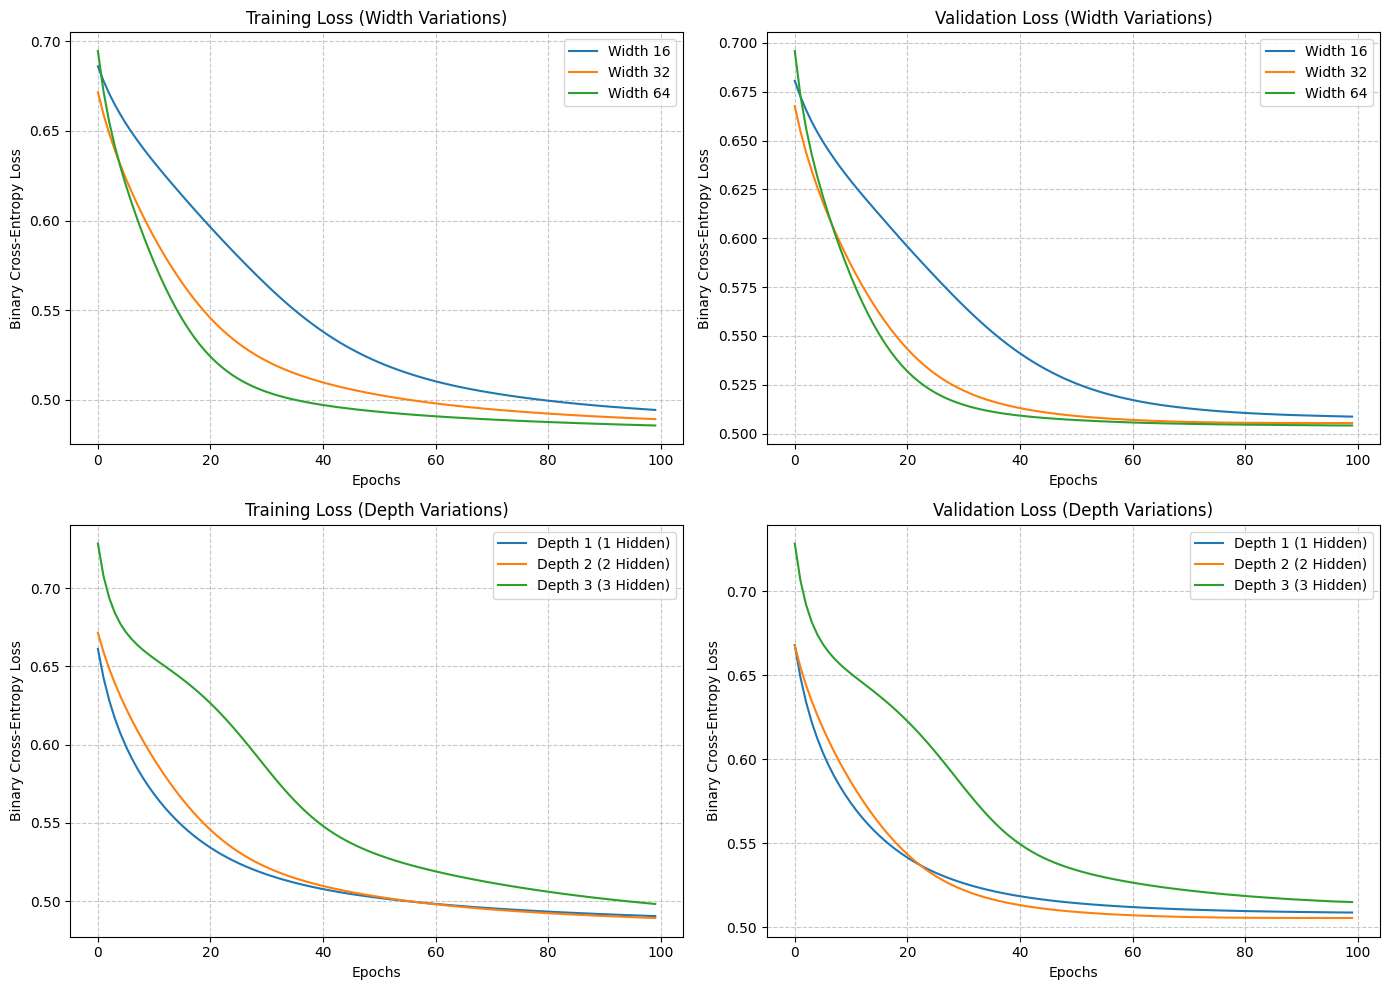

In [43]:
# =====================================================================
# --- EXPERIMENT 1: EFFECT OF DEPTH AND WIDTH ---
# =====================================================================
print("\n" + "="*50)
print("EXPERIMENT 1: DEPTH AND WIDTH VARIATIONS")
print("="*50)

INPUT_DIM = X_train.shape[1]
EPOCHS = 100
BATCH_SIZE = 32
LR = 0.001

# Define variations
# 1. Width variations (Fixed depth: 2 hidden layers)
width_configs = {
    "Width 16": [INPUT_DIM, 16, 16, 1],
    "Width 32": [INPUT_DIM, 32, 32, 1],
    "Width 64": [INPUT_DIM, 64, 64, 1]
}

# 2. Depth variations (Fixed width: 32 neurons per hidden layer)
depth_configs = {
    "Depth 1 (1 Hidden)": [INPUT_DIM, 32, 1],
    "Depth 2 (2 Hidden)": [INPUT_DIM, 32, 32, 1],
    "Depth 3 (3 Hidden)": [INPUT_DIM, 32, 32, 32, 1]
}

def train_and_evaluate(name, layer_sizes):
    # Determine activations: 'relu' for hidden, 'sigmoid' for output
    acts = ["relu"] * (len(layer_sizes) - 2) + ["sigmoid"]
    
    model = ChosenNetwork(layer_sizes=layer_sizes, activations=acts, loss="bce", seed=SEED_VALUE)
    history = model.fit(X_train, y_train, val_data=(X_val, y_val), 
                        epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LR, verbose=0)
    
    y_pred_probs = model.predict(X_val)
    y_pred = (y_pred_probs > 0.5).astype(int)
    f1 = f1_score(y_val, y_pred, average='binary')
    acc = accuracy_score(y_val, y_pred)
    
    print(f"[{name}] F1 Score: {f1:.5f} | Accuracy: {acc:.5f}")
    return history

# Run Width Experiments
print("\n--- Running Width Variations (Fixed 2 Hidden Layers) ---")
width_histories = {}
for name, sizes in width_configs.items():
    width_histories[name] = train_and_evaluate(name, sizes)

# Run Depth Experiments
print("\n--- Running Depth Variations (Fixed 32 Neurons Width) ---")
depth_histories = {}
for name, sizes in depth_configs.items():
    depth_histories[name] = train_and_evaluate(name, sizes)

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot Width Loss
for name, hist in width_histories.items():
    axes[0, 0].plot(hist['train_loss'], label=f"{name}")
    axes[0, 1].plot(hist['val_loss'], label=f"{name}")
axes[0, 0].set_title("Training Loss (Width Variations)")
axes[0, 1].set_title("Validation Loss (Width Variations)")

# Plot Depth Loss
for name, hist in depth_histories.items():
    axes[1, 0].plot(hist['train_loss'], label=f"{name}")
    axes[1, 1].plot(hist['val_loss'], label=f"{name}")
axes[1, 0].set_title("Training Loss (Depth Variations)")
axes[1, 1].set_title("Validation Loss (Depth Variations)")

for ax in axes.flatten():
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Binary Cross-Entropy Loss")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Analisis - Eksperimen 1

#### A. Hasil Prediksi Akhir

**Variasi lebar (width), depth tetap 2 hidden layer:**

| Konfigurasi | F1 Score | Accuracy |
|:-----------:|:--------:|:--------:|
| Width 16 | 0.80016 | 0.74550 |
| Width 32 | 0.79938 | 0.74300 |
| Width 64 | **0.80774** | **0.75150** |

**Variasi kedalaman (depth), width tetap 32:**

| Konfigurasi | F1 Score | Accuracy |
|:-----------:|:--------:|:--------:|
| Depth 1 (1 Hidden) | 0.79752 | 0.73900 |
| Depth 2 (2 Hidden) | **0.79938** | **0.74300** |
| Depth 3 (3 Hidden) | 0.79719 | 0.74000 |

#### B. Interpretasi Kurva Loss

- Semua konfigurasi konvergen; tidak ada indikasi overfitting berat (gap train/val kecil).
- Pada variasi width, konfigurasi lebih lebar cenderung konvergen lebih cepat.
- Pada variasi depth, Depth 3 paling lambat dan tidak mengungguli Depth 2.

**Kesimpulan Eksperimen 1:** konfigurasi terbaik pada run ini adalah **Width 64** (F1 0.80774) dan **Depth 2** (F1 0.79938).

## Eksperimen 2 — Activation Function


EXPERIMENT 2: HIDDEN LAYER 1 ACTIVATION
Base Architecture: [23, 32, 32, 32, 1]
Testing activations on Hidden Layer 1 (Layer index 0)...
[Act: RELU        ] F1 Score: 0.79784
[Act: SIGMOID     ] F1 Score: 0.80386
[Act: TANH        ] F1 Score: 0.80000
[Act: LINEAR      ] F1 Score: 0.80077
[Act: LEAKY_RELU  ] F1 Score: 0.79877
[Act: SWISH       ] F1 Score: 0.80062


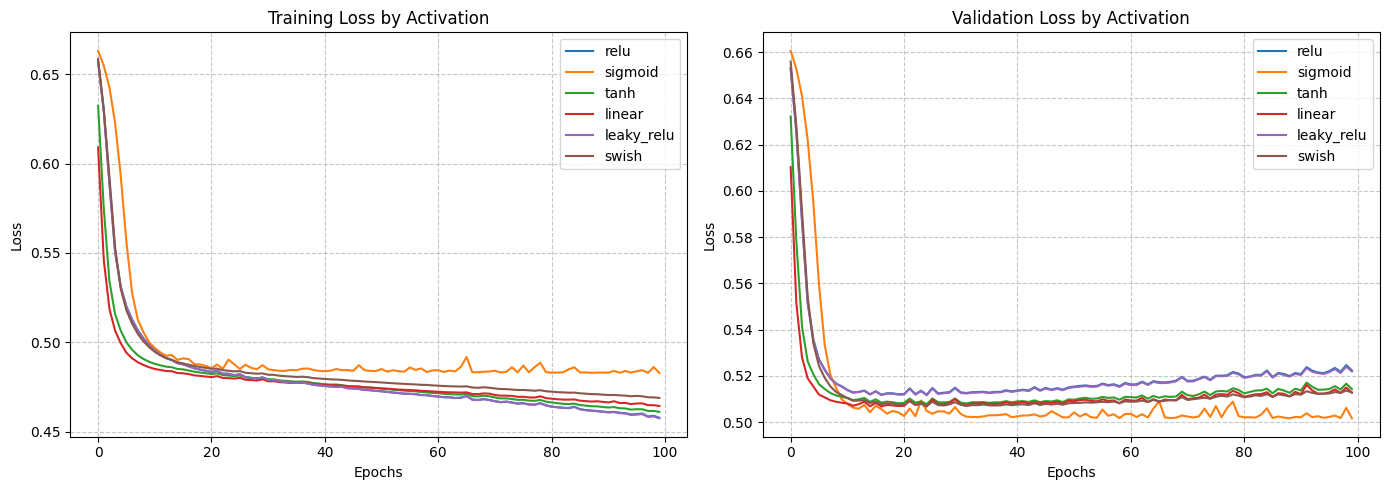


--- Displaying Weight & Gradient Distributions for Layer 0 (The Tested Layer) ---

Distributions for 'relu' activation model:


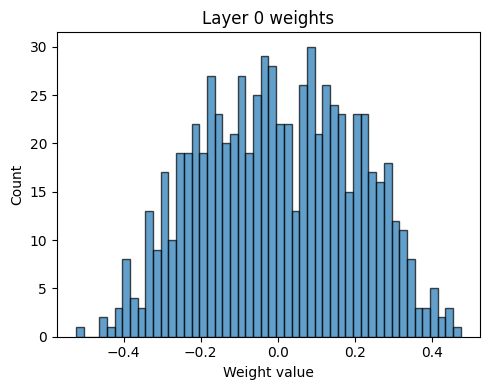

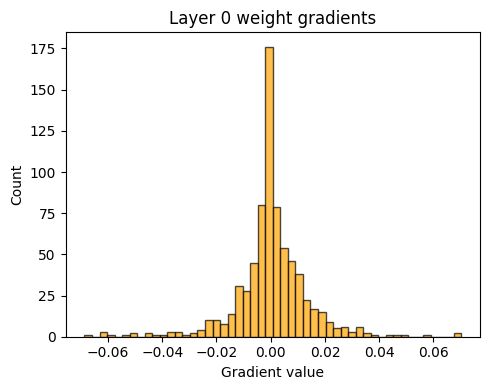


Distributions for 'sigmoid' activation model:


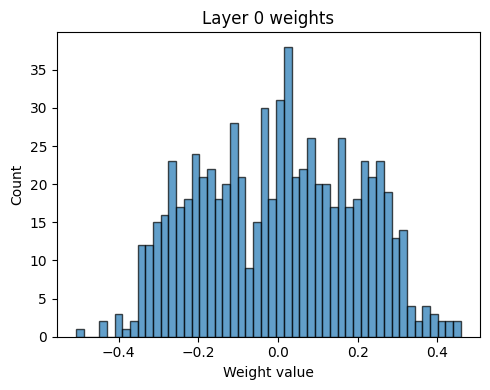

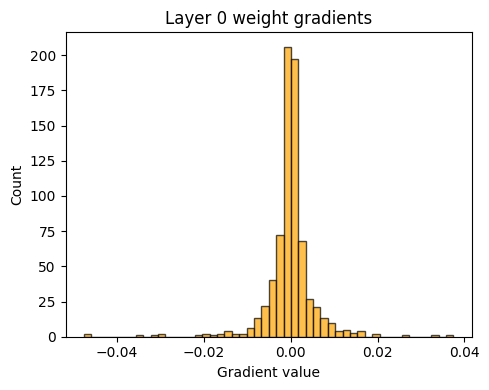


Distributions for 'tanh' activation model:


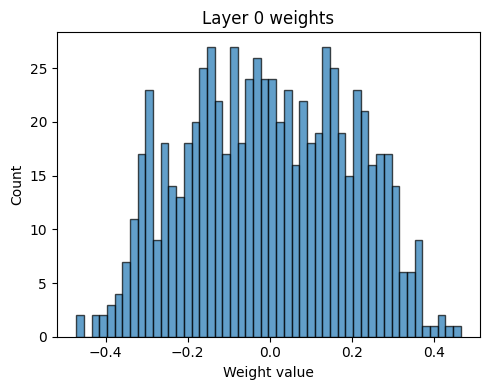

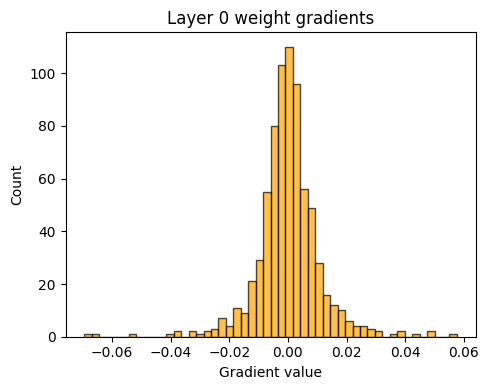


Distributions for 'linear' activation model:


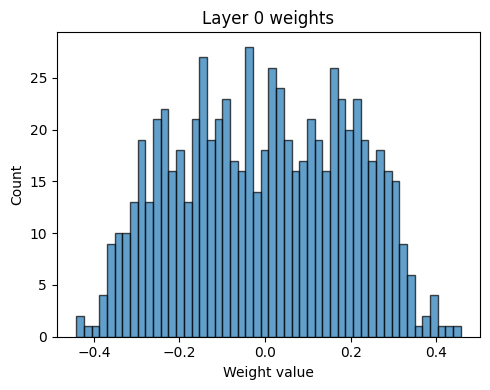

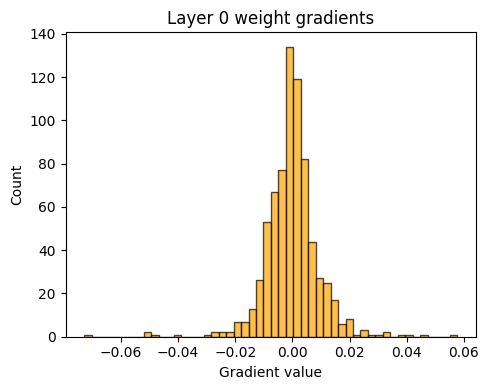


Distributions for 'leaky_relu' activation model:


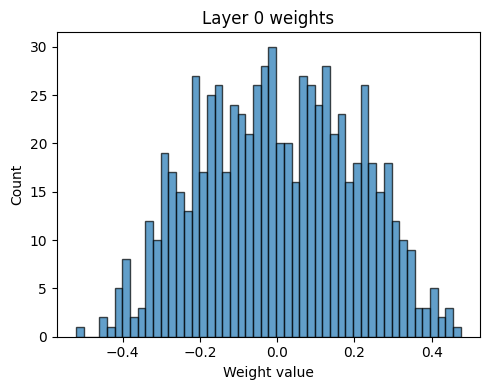

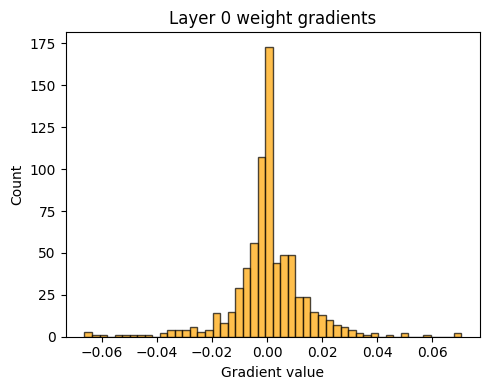


Distributions for 'swish' activation model:


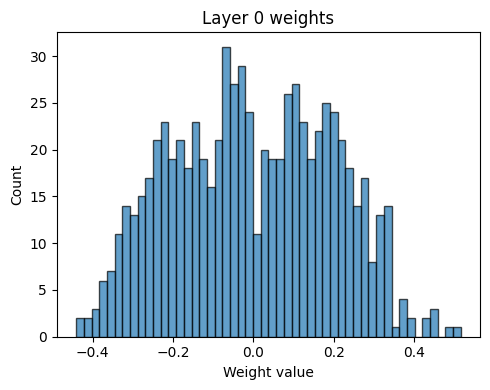

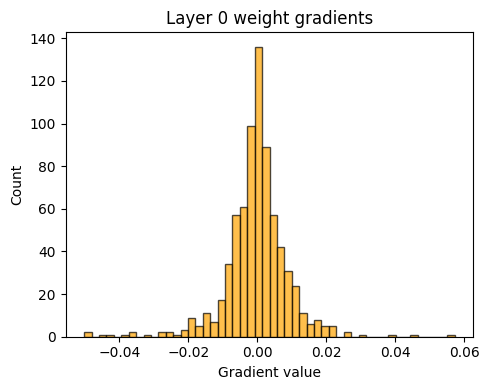

In [44]:
# =====================================================================
# --- EXPERIMENT 2: EFFECT OF ACTIVATION FUNCTIONS ---
# =====================================================================
print("\n" + "="*50)
print("EXPERIMENT 2: HIDDEN LAYER 1 ACTIVATION")
print("="*50)

INPUT_DIM = X_train.shape[1]
BASE_ARCH = [INPUT_DIM, 32, 32, 32, 1] # 3 Hidden Layers
EPOCHS = 100
BATCH_SIZE = 32
LR = 0.01

test_activations = ["relu", "sigmoid", "tanh", "linear", "leaky_relu", "swish"]
act_histories = {}
act_models = {}

print("Base Architecture:", BASE_ARCH)
print("Testing activations on Hidden Layer 1 (Layer index 0)...")

for act in test_activations:
    # First hidden uses 'act', second & third hidden uses 'relu', output uses 'sigmoid'
    activations_list = [act, "relu", "relu", "sigmoid"]
    
    model = ChosenNetwork(layer_sizes=BASE_ARCH, activations=activations_list, loss="bce", seed=SEED_VALUE)
    history = model.fit(X_train, y_train, val_data=(X_val, y_val), 
                        epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LR, verbose=0)
    
    y_pred_probs = model.predict(X_val)
    y_pred = (y_pred_probs > 0.5).astype(int)
    f1 = f1_score(y_val, y_pred, average='binary')
    
    print(f"[Act: {act.upper():<12}] F1 Score: {f1:.5f}")
    
    act_histories[act] = history
    act_models[act] = model

# --- Plotting Training & Val Loss ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for act, hist in act_histories.items():
    axes[0].plot(hist['train_loss'], label=f"{act}")
    axes[1].plot(hist['val_loss'], label=f"{act}")

axes[0].set_title("Training Loss by Activation")
axes[1].set_title("Validation Loss by Activation")
for ax in axes:
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plotting Weight and Gradient Distributions ---
print("\n--- Displaying Weight & Gradient Distributions for Layer 0 (The Tested Layer) ---")
for act, model in act_models.items():
    print(f"\nDistributions for '{act}' activation model:")
    model.plot_weight_distribution(layers=[0])
    model.plot_gradient_distribution(layers=[0])

### Analisis - Eksperimen 2

#### A. Hasil Prediksi Akhir

**F1 Score per fungsi aktivasi pada hidden layer 1 (arsitektur [23, 32, 32, 32, 1]):**

| Aktivasi | F1 Score |
|:--------:|:--------:|
| **Sigmoid** | **0.80386** |
| Linear | 0.80077 |
| Swish | 0.80062 |
| Tanh | 0.80000 |
| Leaky ReLU | 0.79877 |
| ReLU | 0.79784 |

#### B. Interpretasi Kurva Loss

- ReLU, Leaky ReLU, dan Swish menurun lebih cepat di fase awal training.
- Sigmoid menurun lebih lambat, tetapi menghasilkan F1 akhir tertinggi pada validasi.
- Seluruh konfigurasi berakhir pada rentang val_loss yang berdekatan, sehingga perbedaan performa akhir relatif kecil.

#### C. Interpretasi Bobot dan Gradien

- Sigmoid cenderung memiliki gradien lebih sempit di sekitar nol, konsisten dengan kecenderungan vanishing gradient lokal.
- ReLU-family menunjukkan distribusi gradien lebih tersebar dan stabil.
- Karena hanya layer pertama yang diuji, efek perbedaan aktivasi terhadap performa total tetap terbatas.

**Kesimpulan Eksperimen 2:** **Sigmoid** memberi F1 terbaik (**0.80386**), tetapi margin terhadap aktivasi lain kecil sehingga sensitivitas terhadap pilihan aktivasi tidak besar untuk dataset ini.

## Eksperimen 3 — Learning Rate


EXPERIMENT 3: LEARNING RATE VARIATIONS
[LR: 0.1   ] F1 Score: 0.7682
[LR: 0.01  ] F1 Score: 0.7958
[LR: 0.001 ] F1 Score: 0.7994


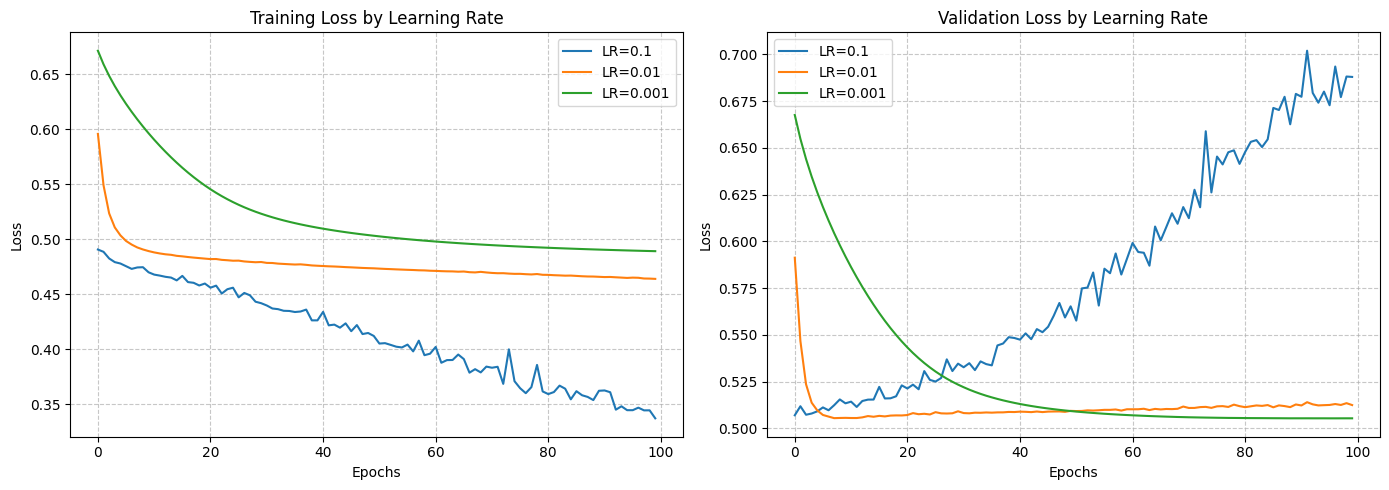


--- Displaying Distributions (Showing Layer 1 for each LR) ---

Distributions for LR=0.1:


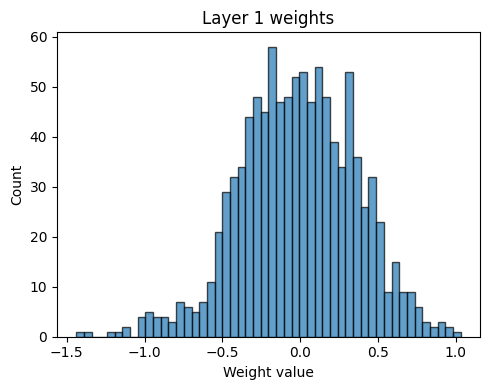

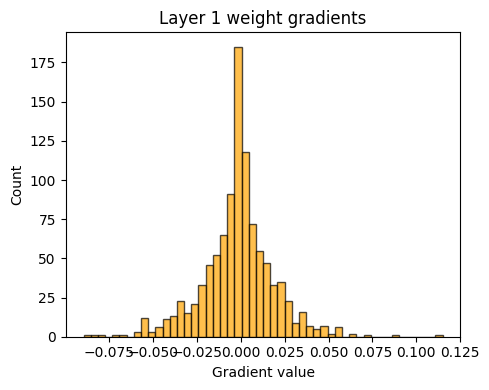


Distributions for LR=0.01:


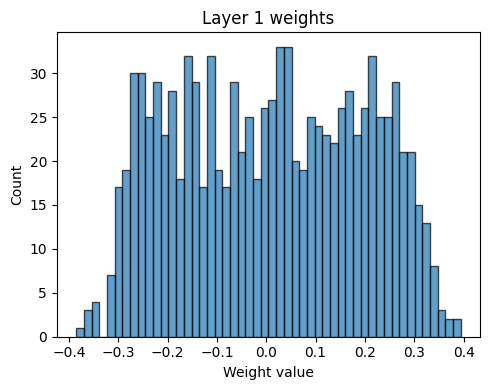

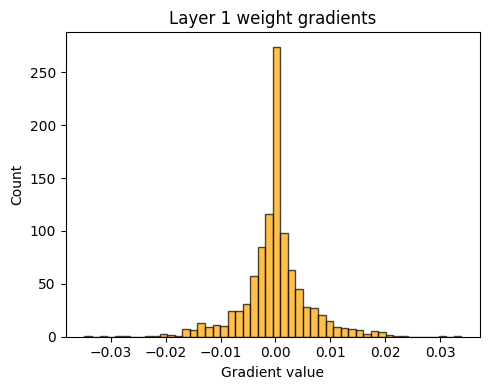


Distributions for LR=0.001:


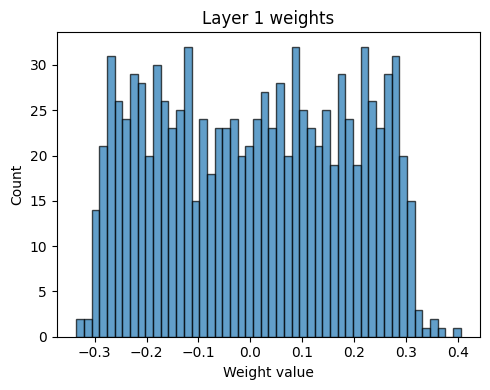

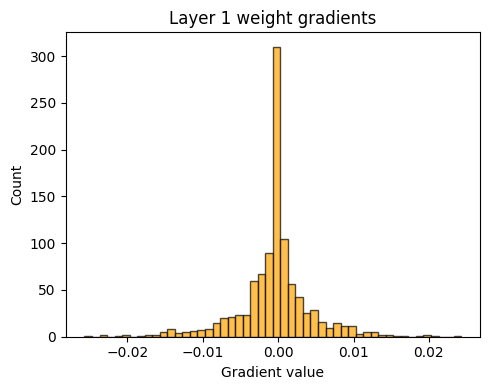

In [45]:
# =====================================================================
# --- EXPERIMENT 3: EFFECT OF LEARNING RATE ---
# =====================================================================
print("\n" + "="*50)
print("EXPERIMENT 3: LEARNING RATE VARIATIONS")
print("="*50)

INPUT_DIM = X_train.shape[1]
BASE_ARCH = [INPUT_DIM, 32, 32, 1]
ACTIVATIONS = ["relu", "relu", "sigmoid"]
EPOCHS = 100
BATCH_SIZE = 32

learning_rates = [0.1, 0.01, 0.001]
lr_histories = {}
lr_models = {}

for lr in learning_rates:
    model = ChosenNetwork(layer_sizes=BASE_ARCH, activations=ACTIVATIONS, loss="bce", seed=SEED_VALUE)
    history = model.fit(X_train, y_train, val_data=(X_val, y_val), 
                        epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=lr, verbose=0)
    
    y_pred_probs = model.predict(X_val)
    y_pred = (y_pred_probs > 0.5).astype(int)
    f1 = f1_score(y_val, y_pred, average='binary')
    
    print(f"[LR: {lr:<6}] F1 Score: {f1:.4f}")
    
    lr_histories[lr] = history
    lr_models[lr] = model

# --- Plotting Training & Val Loss ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lr, hist in lr_histories.items():
    axes[0].plot(hist['train_loss'], label=f"LR={lr}")
    axes[1].plot(hist['val_loss'], label=f"LR={lr}")

axes[0].set_title("Training Loss by Learning Rate")
axes[1].set_title("Validation Loss by Learning Rate")
for ax in axes:
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plotting Weight and Gradient Distributions ---
print("\n--- Displaying Distributions (Showing Layer 1 for each LR) ---")
for lr, model in lr_models.items():
    print(f"\nDistributions for LR={lr}:")
    model.plot_weight_distribution(layers=[1])
    model.plot_gradient_distribution(layers=[1])

### Analisis - Eksperimen 3

#### A. Hasil Prediksi Akhir

**F1 Score per learning rate (arsitektur [INPUT, 32, 32, 1], aktivasi ReLU-ReLU-Sigmoid):**

| Learning Rate | F1 Score |
|:-------------:|:--------:|
| 0.1 | 0.7682 |
| 0.01 | 0.7958 |
| **0.001** | **0.7994** |

#### B. Interpretasi Kurva Loss

- **LR = 0.1** menurunkan training loss cepat, tetapi validation loss meningkat tajam (langkah update terlalu agresif).
- **LR = 0.01** paling stabil dari sisi proses konvergensi dalam 100 epoch.
- **LR = 0.001** paling lambat konvergen, namun memberi F1 akhir validasi tertinggi pada run ini.

#### C. Implikasi ke Update Bobot

Rumus update bobot:

$$W_{t+1} = W_t - \eta \nabla_W \mathcal{L}$$

- Nilai $\eta$ besar mempercepat langkah, tetapi meningkatkan risiko osilasi.
- Nilai $\eta$ kecil lebih aman, tetapi butuh epoch lebih banyak untuk konvergen.

**Kesimpulan Eksperimen 3:** jika target utama adalah F1 akhir, pilih **LR = 0.001**; jika target utama adalah kecepatan dan stabilitas proses training, **LR = 0.01** tetap praktis.

## Eksperimen 4 — Initialization



EXPERIMENT 4: WEIGHT INITIALIZATION
[Init: zero    ] F1 Score: 0.76657
[Init: uniform ] F1 Score: 0.79263
[Init: normal  ] F1 Score: 0.79064
[Init: xavier  ] F1 Score: 0.79938
[Init: he      ] F1 Score: 0.79922


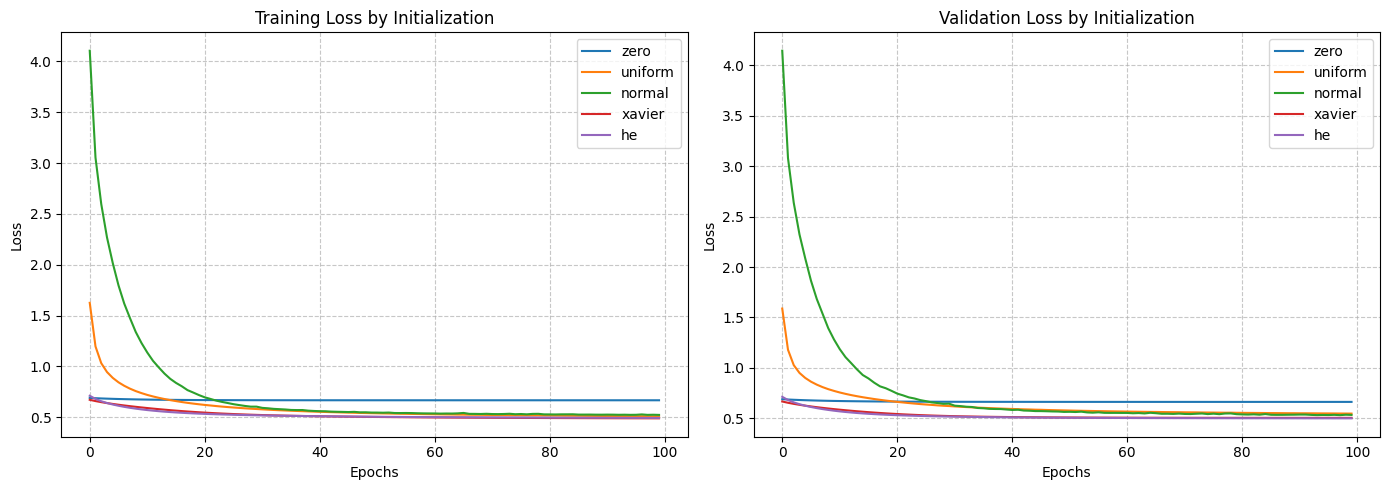


--- Displaying Distributions (Hidden Layers 0 and 1 only) ---

Distributions for Init = zero:


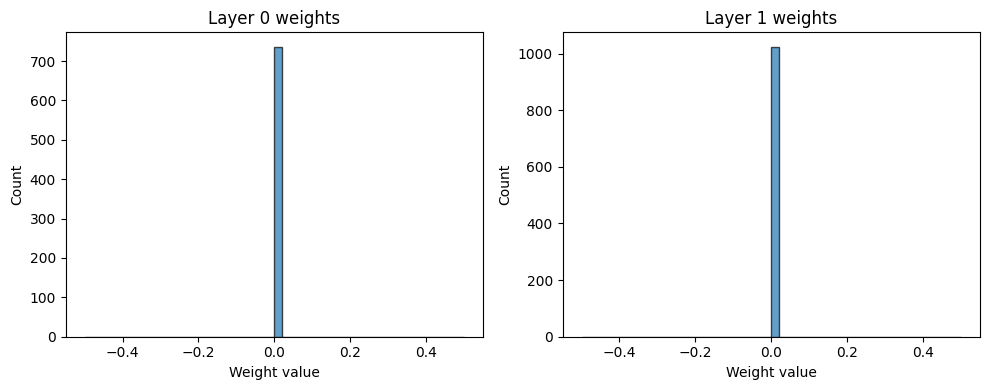

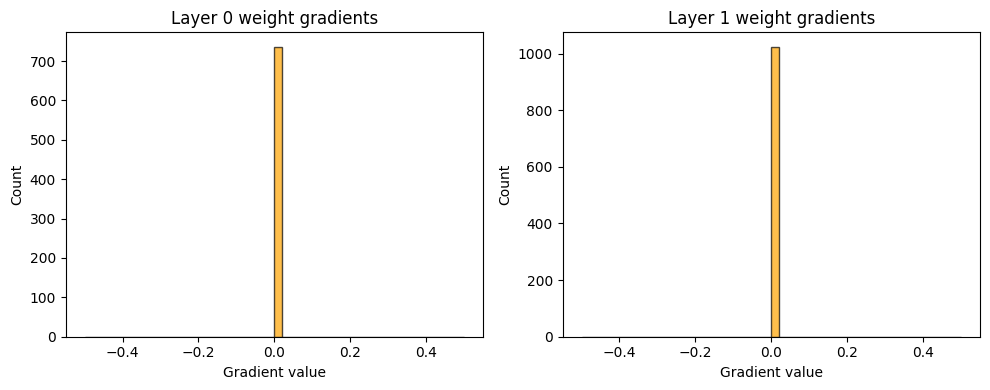


Distributions for Init = uniform:


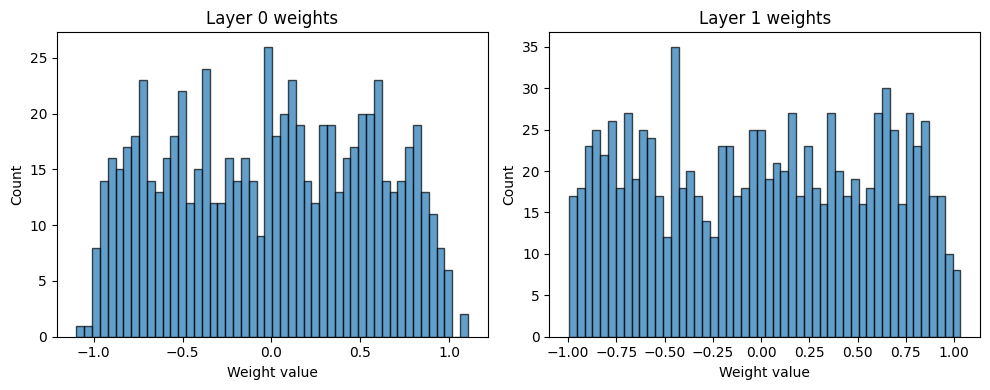

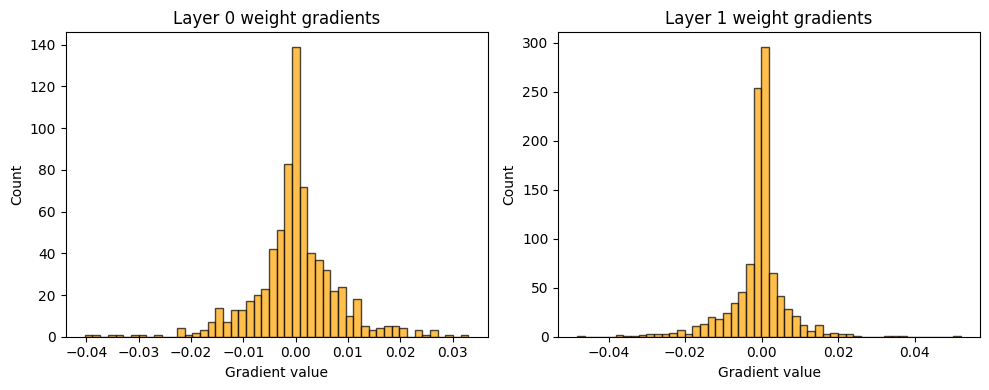


Distributions for Init = normal:


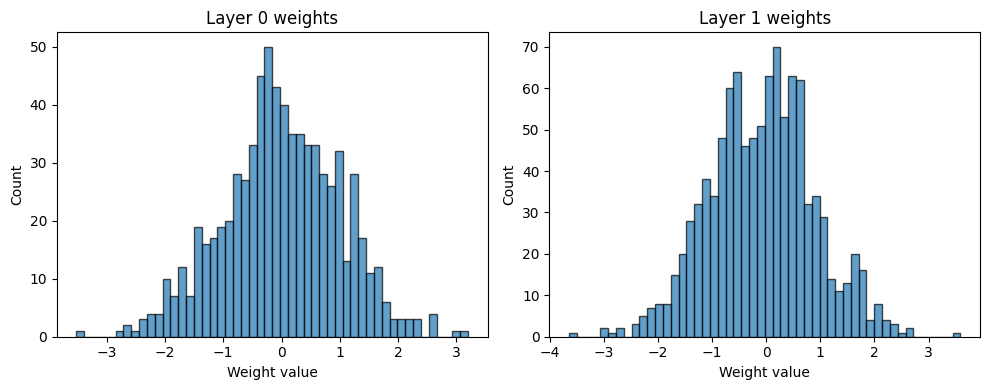

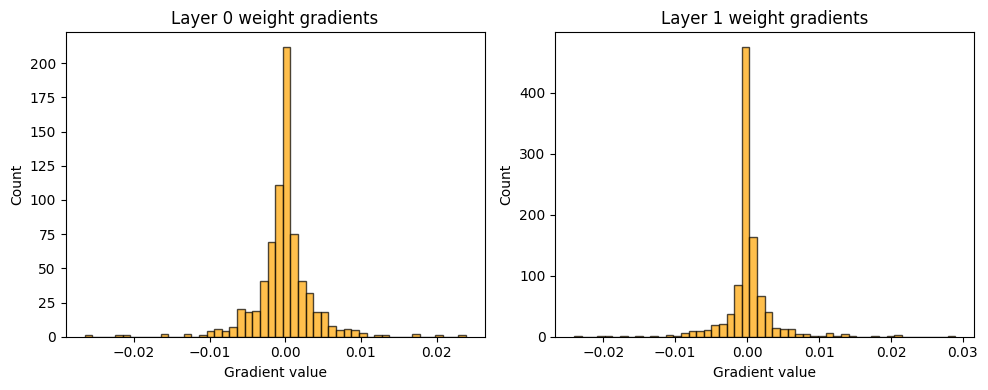


Distributions for Init = xavier:


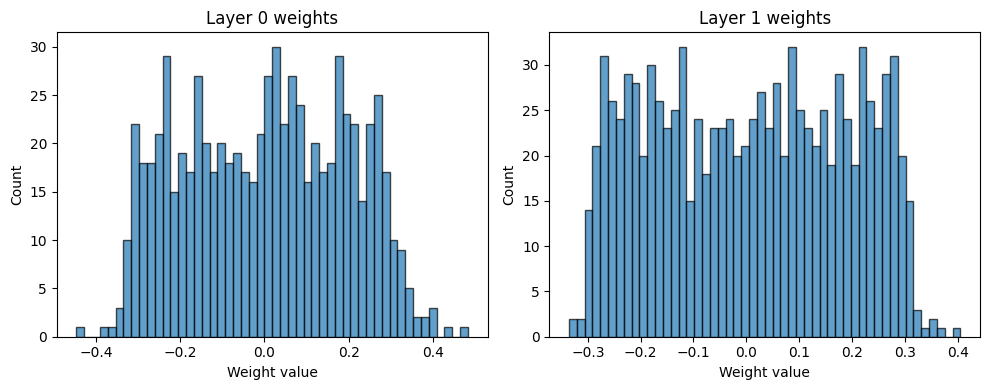

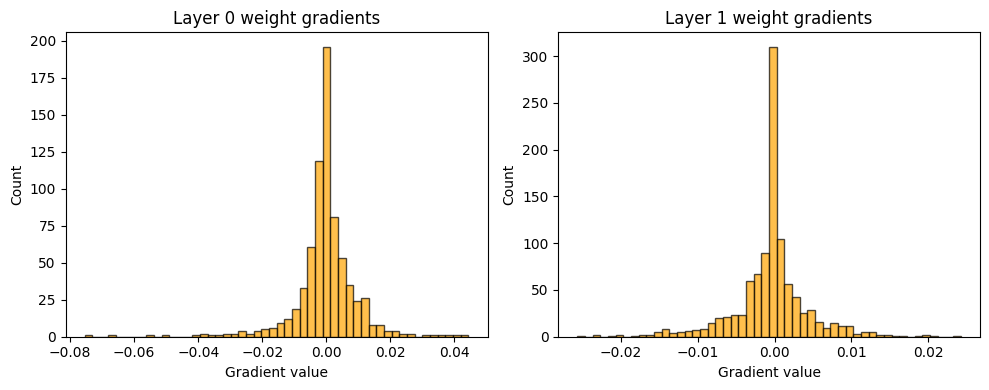


Distributions for Init = he:


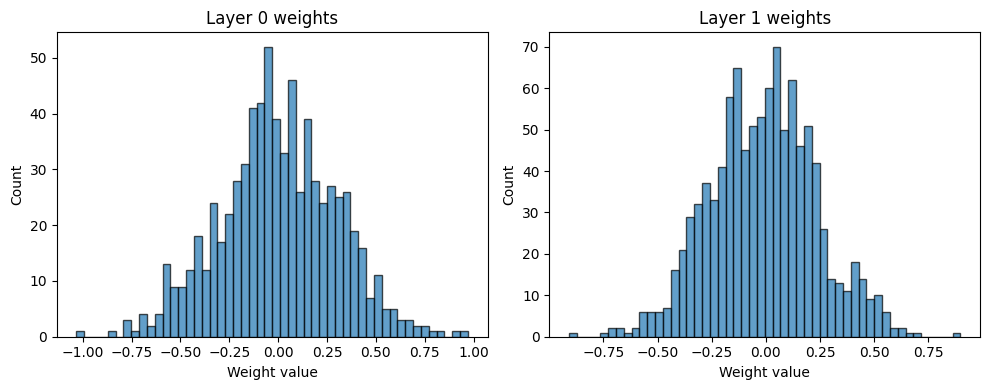

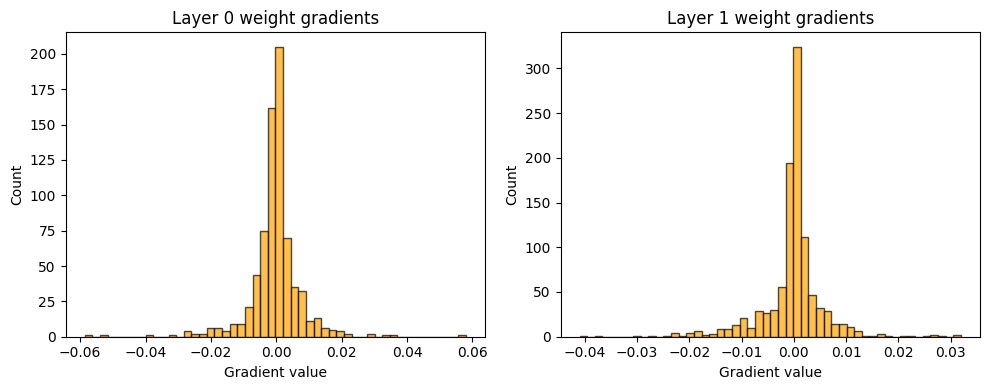

In [46]:
# =====================================================================
# --- EXPERIMENT 4: EFFECT OF WEIGHT INITIALIZATION ---
# =====================================================================
print("\n" + "="*50)
print("EXPERIMENT 4: WEIGHT INITIALIZATION")
print("="*50)

INPUT_DIM = X_train.shape[1]
BASE_ARCH = [INPUT_DIM, 32, 32, 1]
ACTIVATIONS = ["relu", "relu", "sigmoid"]
EPOCHS = 100
BATCH_SIZE = 32
LR = 0.001

# Available initializers: "zero", "uniform", "normal", "xavier", "he"
init_configs = ["zero", "uniform", "normal", "xavier", "he"]
init_histories = {}
init_models = {}

for init_name in init_configs:
    model = ChosenNetwork(
        layer_sizes=BASE_ARCH,
        activations=ACTIVATIONS,
        loss="bce",
        seed=SEED_VALUE,
        initializer=init_name
    )

    history = model.fit(X_train, y_train, val_data=(X_val, y_val),
                        epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LR, verbose=0)

    y_pred_probs = model.predict(X_val)
    y_pred = (y_pred_probs > 0.5).astype(int)
    f1 = f1_score(y_val, y_pred, average='binary')

    print(f"[Init: {init_name:<8}] F1 Score: {f1:.5f}")

    init_histories[init_name] = history
    init_models[init_name] = model

# --- Plotting Training & Val Loss ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for init_name, hist in init_histories.items():
    axes[0].plot(hist['train_loss'], label=f"{init_name}")
    axes[1].plot(hist['val_loss'], label=f"{init_name}")

axes[0].set_title("Training Loss by Initialization")
axes[1].set_title("Validation Loss by Initialization")
for ax in axes:
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plotting Weight and Gradient Distributions ---
# Layer 0: INPUT->32 (hidden), Layer 1: 32->32 (hidden), Layer 2: 32->1 (output — excluded)
print("\n--- Displaying Distributions (Hidden Layers 0 and 1 only) ---")
for init_name, model in init_models.items():
    print(f"\nDistributions for Init = {init_name}:")
    model.plot_weight_distribution(layers=[0, 1])
    model.plot_gradient_distribution(layers=[0, 1])


### Analisis - Eksperimen 4

#### A. Hasil Prediksi Akhir

**F1 Score per metode inisialisasi (arsitektur [INPUT, 32, 32, 1], aktivasi ReLU-ReLU-Sigmoid, LR = 0.001):**

| Inisialisasi | F1 Score |
|:------------:|:--------:|
| Zero | 0.76657 |
| Uniform | 0.79263 |
| Normal | 0.79064 |
| **Xavier** | **0.79938** |
| He | 0.79922 |

#### B. Interpretasi Kurva Loss

- **Xavier** dan **He** sama-sama stabil dan konvergen baik.
- **Uniform** dan **Normal** masih kompetitif, tetapi sedikit di bawah Xavier/He.
- **Zero** paling lemah dan cenderung stagnan karena masalah symmetry.

#### C. Interpretasi Bobot dan Gradien

- Xavier/He menghasilkan distribusi bobot-gradien yang paling seimbang untuk konfigurasi ini.
- Normal/Uniform cenderung lebih lebar di awal lalu menyempit saat training.
- Zero menghasilkan variasi bobot yang buruk pada fase awal, sehingga pembelajaran lambat.

**Kesimpulan Eksperimen 4:** performa terbaik pada run ini adalah **Xavier (0.79938)**, sangat dekat dengan **He (0.79922)**.

## Eksperimen 5 — Regularization



EXPERIMENT 5: REGULARIZATION (L1 vs L2 vs None)
[Regularization: None] F1 Score: 0.79938
[Regularization: l1  ] F1 Score: 0.79906
[Regularization: l2  ] F1 Score: 0.80016


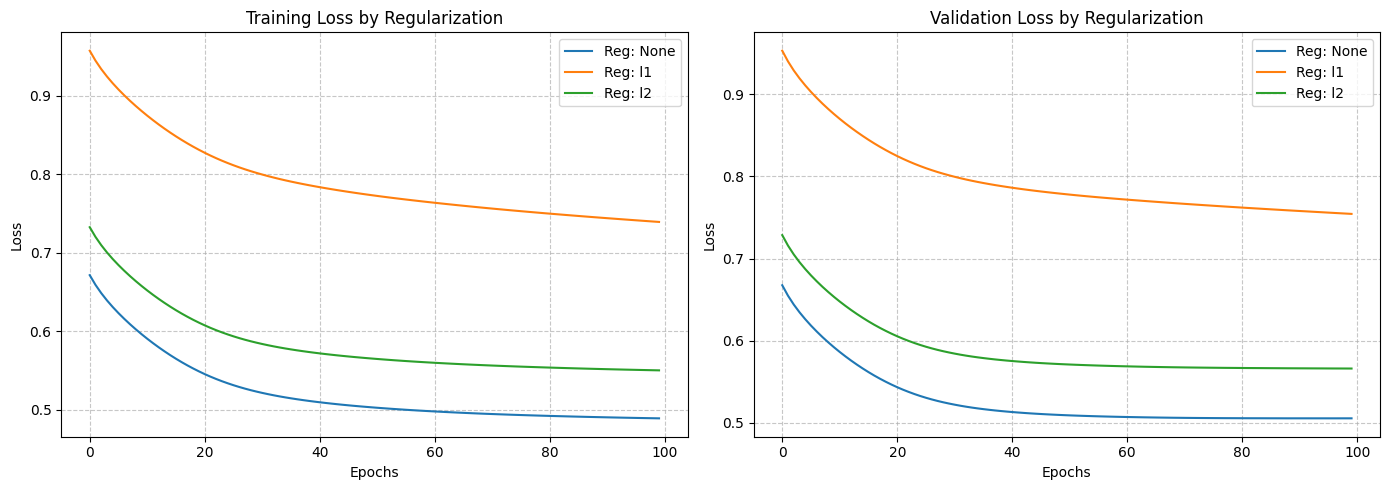


--- Displaying Distributions (Hidden Layers 0 and 1 only) ---

Distributions for Regularization = None:


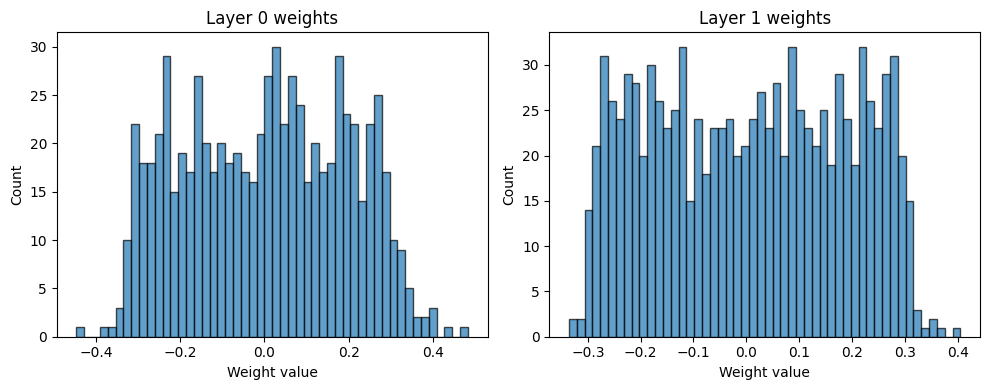

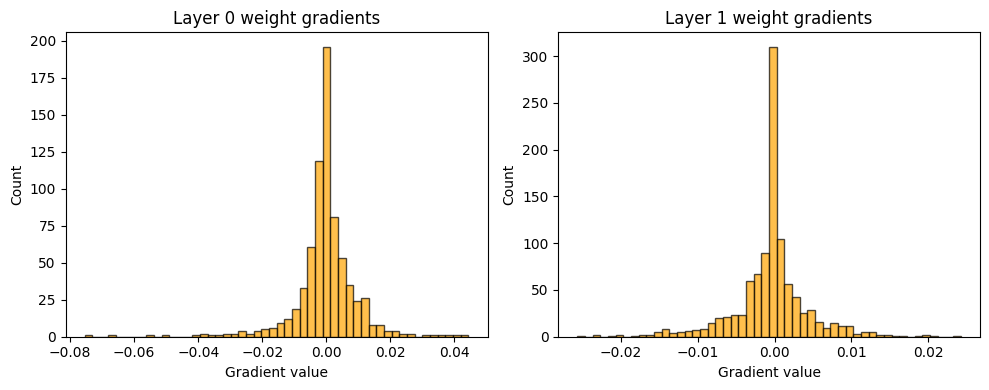


Distributions for Regularization = l1:


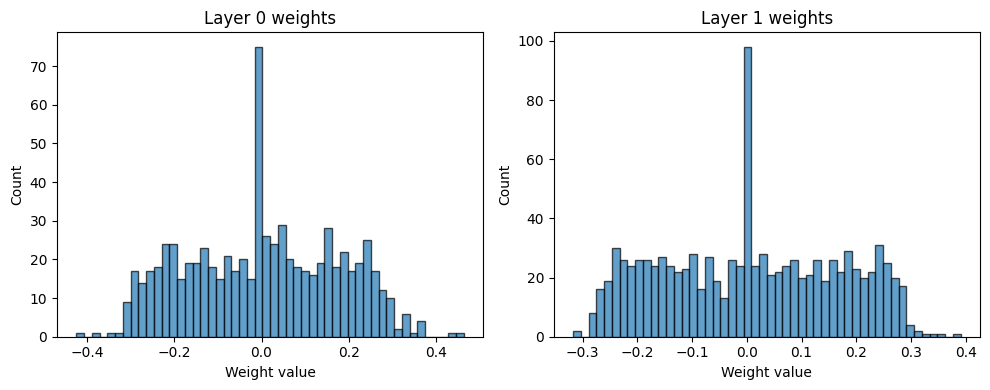

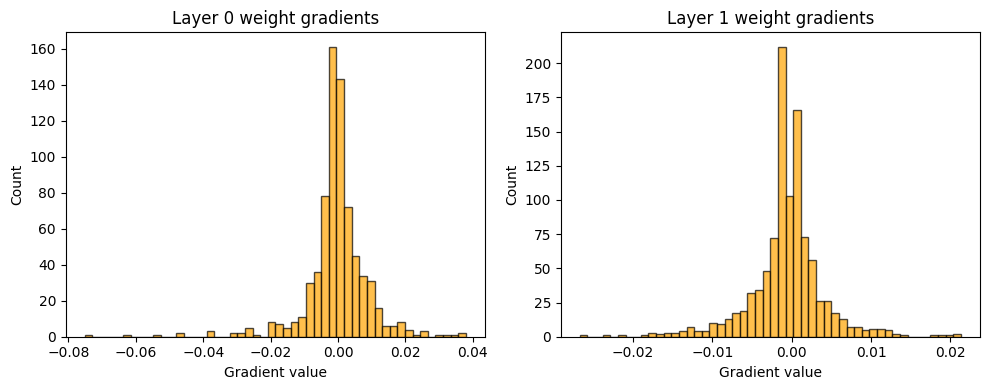


Distributions for Regularization = l2:


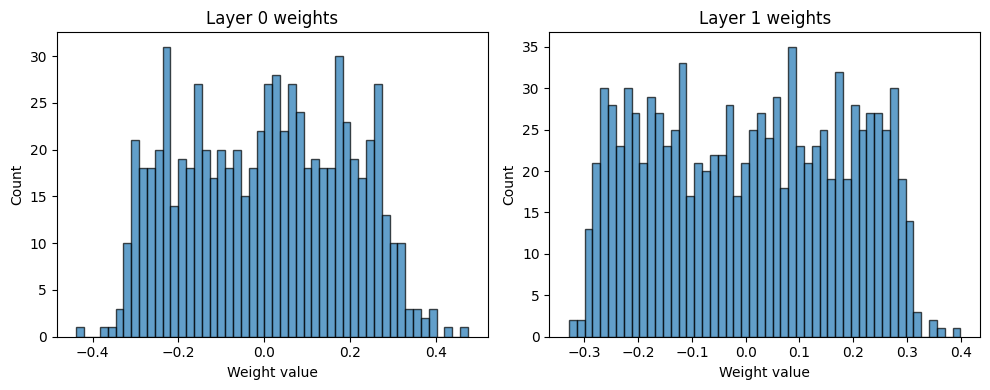

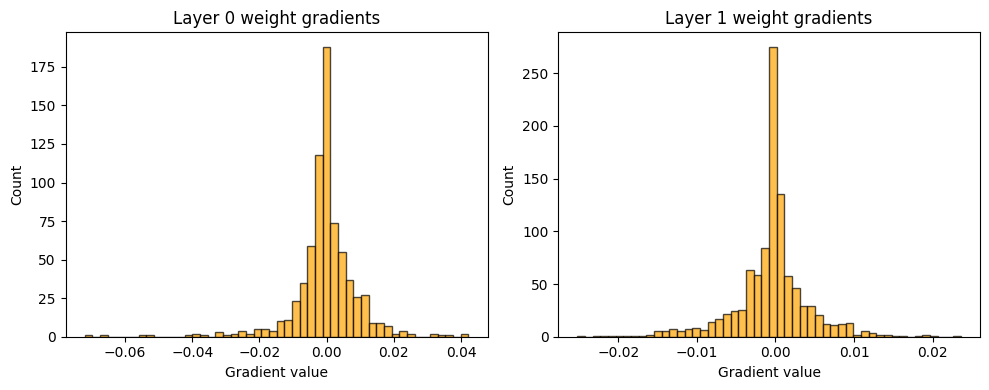

In [47]:
# =====================================================================
# --- EXPERIMENT 5: EFFECT OF REGULARIZATION ---
# =====================================================================
print("\n" + "="*50)
print("EXPERIMENT 5: REGULARIZATION (L1 vs L2 vs None)")
print("="*50)

INPUT_DIM = X_train.shape[1]
BASE_ARCH = [INPUT_DIM, 32, 32, 1]
ACTIVATIONS = ["relu", "relu", "sigmoid"]
EPOCHS = 100
BATCH_SIZE = 32
LR = 0.001
REG_LAMBDA = 0.001

reg_configs = [None, "l1", "l2"]
reg_histories = {}
reg_models = {}

for reg in reg_configs:
    reg_name = reg if reg is not None else "None"
    
    model = ChosenNetwork(layer_sizes=BASE_ARCH, activations=ACTIVATIONS, loss="bce", 
                          seed=SEED_VALUE, regularization=reg, reg_lambda=REG_LAMBDA if reg else 0.0)
    
    history = model.fit(X_train, y_train, val_data=(X_val, y_val), 
                        epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LR, verbose=0)
    
    y_pred_probs = model.predict(X_val)
    y_pred = (y_pred_probs > 0.5).astype(int)
    f1 = f1_score(y_val, y_pred, average='binary')
    
    print(f"[Regularization: {reg_name:<4}] F1 Score: {f1:.5f}")
    
    reg_histories[reg_name] = history
    reg_models[reg_name] = model

# --- Plotting Training & Val Loss ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for reg_name, hist in reg_histories.items():
    axes[0].plot(hist['train_loss'], label=f"Reg: {reg_name}")
    axes[1].plot(hist['val_loss'], label=f"Reg: {reg_name}")

axes[0].set_title("Training Loss by Regularization")
axes[1].set_title("Validation Loss by Regularization")
for ax in axes:
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plotting Weight and Gradient Distributions ---
# Layer 0: INPUT->32 (hidden), Layer 1: 32->32 (hidden), Layer 2: 32->1 (output — excluded)
print("\n--- Displaying Distributions (Hidden Layers 0 and 1 only) ---")
for reg_name, model in reg_models.items():
    print(f"\nDistributions for Regularization = {reg_name}:")
    model.plot_weight_distribution(layers=[0, 1])
    model.plot_gradient_distribution(layers=[0, 1])


### Analisis - Eksperimen 5

#### A. Hasil Prediksi Akhir

**F1 Score per konfigurasi regularisasi (arsitektur [INPUT, 32, 32, 1], LR = 0.001, lambda = 0.001):**

| Regularisasi | F1 Score |
|:------------:|:--------:|
| None | 0.79938 |
| L1 | 0.79906 |
| **L2** | **0.80016** |

#### B. Interpretasi Kurva Loss

- Ketiga konfigurasi menunjukkan konvergensi yang mirip.
- L1 dan L2 memberi pembatasan bobot, sementara None memberi kebebasan penuh pada bobot.
- Pada run ini, L2 menghasilkan generalisasi terbaik menurut metrik F1.

#### C. Interpretasi Bobot dan Gradien

- **None:** bobot berkembang tanpa penalti.
- **L1:** mendorong sparsitas (lebih banyak bobot mendekati nol).
- **L2:** mendorong penyusutan bobot secara halus (weight decay) dan biasanya lebih stabil.

**Kesimpulan Eksperimen 5:** konfigurasi terbaik adalah **L2** dengan **F1 = 0.80016**.

## Eksperimen 6 — Perbandingan dengan Sklearn MLPClassifier


--- Training Sklearn MLPClassifier (Uniform Activation) ---
  Sklearn activation: 'identity'
  Mapped to ours   : 'linear'


/Users/yonatanedwardnjoto/Documents/kuliah/ML-FFNN/src/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



--- Training ChosenNetwork (Uniform Activation: 'linear') ---

Best config summary:
  Architecture     : [23, 128, 32, 128, 1]
  Hidden Activation: identity (ours: linear)
  Learning rate    : 0.001
  Regulariz.       : None (to match Sklearn)

  MODEL COMPARISON (1:1 PARAMS)
  Sklearn  MLPClassifier F1: 0.8014
  ChosenNetwork          F1: 0.8015


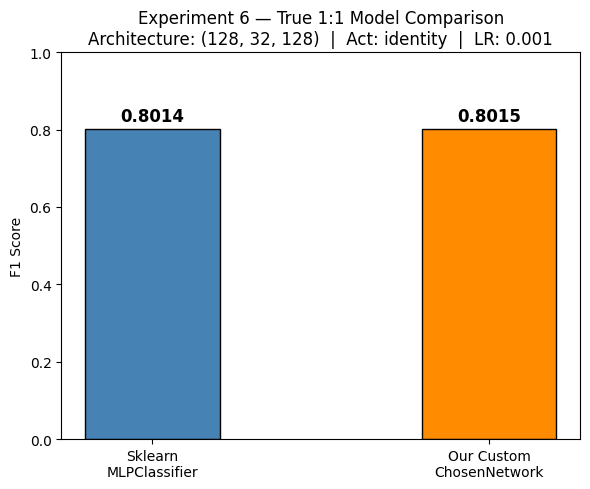

In [48]:
# --- 1. MANUAL CONFIGURATION ---
EPOCHS = 300
BATCH_SIZE = 32
LEARNING_RATE = 0.001

# Architecture
INPUT_DIM = X_train.shape[1]
HIDDEN_LAYERS = (128, 32, 128)                 # For sklearn (hidden only)
LAYER_SIZES = [INPUT_DIM, 128, 32, 128, 1]     # For ChosenNetwork (input + hidden + output)

# Activations (uniform for hidden layers)
SKLEARN_ACT = "identity"  # sklearn activation choices: identity, logistic, tanh, relu
SKLEARN_ACT = SKLEARN_ACT.lower()

SKLEARN_TO_OURS_ACTIVATION = {
    "identity": "linear",
    "logistic": "sigmoid",
    "tanh": "tanh",
    "relu": "relu",
}

if SKLEARN_ACT not in SKLEARN_TO_OURS_ACTIVATION:
    raise ValueError(
        f"Unsupported sklearn activation '{SKLEARN_ACT}'. "
        f"Supported: {list(SKLEARN_TO_OURS_ACTIVATION.keys())}"
    )

UNIFORM_ACT_OURS = SKLEARN_TO_OURS_ACTIVATION[SKLEARN_ACT]

print("\n--- Training Sklearn MLPClassifier (Uniform Activation) ---")
print(f"  Sklearn activation: '{SKLEARN_ACT}'")
print(f"  Mapped to ours   : '{UNIFORM_ACT_OURS}'")

# --- 2. TRAIN SKLEARN (Uniform Hidden Activations) ---
np.random.seed(SEED_VALUE)
sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=HIDDEN_LAYERS,
    activation=SKLEARN_ACT,
    solver='sgd',
    batch_size=BATCH_SIZE,
    learning_rate_init=LEARNING_RATE,
    learning_rate='constant',       # Ensure LR doesn't decay
    max_iter=EPOCHS,
    alpha=0.0,                      # Turn off sklearn's default L2
    momentum=0.0,                   # Turn off default momentum for vanilla SGD
    nesterovs_momentum=False,
    tol=0.0,                        # Force it to run all epochs
    n_iter_no_change=EPOCHS,
    shuffle=True,
    random_state=SEED_VALUE
)

sklearn_mlp.fit(X_train, y_train.ravel())
y_pred_sklearn = sklearn_mlp.predict(X_val)
f1_sklearn = f1_score(y_val, y_pred_sklearn, average='binary')

# --- 3. TRAIN CHOSEN NETWORK (Uniform Hidden Activations) ---
print(f"\n--- Training ChosenNetwork (Uniform Activation: '{UNIFORM_ACT_OURS}') ---")
uniform_acts_list = [UNIFORM_ACT_OURS] * len(HIDDEN_LAYERS) + ["sigmoid"]

model_uniform = ChosenNetwork(
    layer_sizes=LAYER_SIZES,
    activations=uniform_acts_list,
    loss="bce",
    seed=SEED_VALUE,
    regularization=None,  # Matching sklearn's alpha=0.0
    reg_lambda=0.0
)
model_uniform.fit(
    X_train=X_train, y_train=y_train,
    val_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE, verbose=0
)

y_pred_uniform = (model_uniform.predict(X_val) > 0.5).astype(int)
f1_uniform = f1_score(y_val, y_pred_uniform, average='binary')

# --- 4. RESULTS & VISUALIZATION ---
print(f"\nBest config summary:")
print(f"  Architecture     : {LAYER_SIZES}")
print(f"  Hidden Activation: {SKLEARN_ACT} (ours: {UNIFORM_ACT_OURS})")
print(f"  Learning rate    : {LEARNING_RATE}")
print(f"  Regulariz.       : None (to match Sklearn)")

print(f"\n{'='*60}")
print(f"  MODEL COMPARISON (1:1 PARAMS)")
print(f"{'='*60}")
print(f"  Sklearn  MLPClassifier F1: {f1_sklearn:.4f}")
print(f"  ChosenNetwork          F1: {f1_uniform:.4f}")
print(f"{'='*60}")

# Bar chart comparison
labels = ["Sklearn\nMLPClassifier", "Our Custom\nChosenNetwork"]
scores = [f1_sklearn, f1_uniform]
colors = ['steelblue', 'darkorange']

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, scores, color=colors, width=0.4, edgecolor='black')
ax.set_ylim(0, 1.0)
ax.set_ylabel("F1 Score")
ax.set_title(f"Experiment 6 — True 1:1 Model Comparison\nArchitecture: {HIDDEN_LAYERS}  |  Act: {SKLEARN_ACT}  |  LR: {LEARNING_RATE}")
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{score:.4f}", ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Analisis - Eksperimen 6

#### A. Hasil Prediksi Akhir

**Perbandingan F1 Score (arsitektur [INPUT, 128, 32, 128, 1], aktivasi Linear uniform, LR = 0.001):**

| Model | F1 Score |
|:-----:|:--------:|
| Sklearn MLPClassifier | 0.8014 |
| **FFNN Buatan Sendiri** | **0.8015** |

#### B. Interpretasi

- Performa kedua model sangat dekat, dengan keunggulan tipis pada model FFNN buatan sendiri.
- Sklearn masih menampilkan **ConvergenceWarning** (maksimum iterasi tercapai), sehingga hasilnya masih bisa berubah jika iterasi ditambah.
- Hasil ini mendukung bahwa implementasi FFNN buatan sendiri sudah sebanding dengan baseline pustaka populer.

**Kesimpulan Eksperimen 6:** pada konfigurasi ini, FFNN buatan sendiri unggul tipis (**+0.0001 F1**) terhadap sklearn.

## 5. Rangkuman Akhir

| Eksperimen | Aspek yang Diuji | Pilihan Terbaik | F1 Score |
|:----------:|:----------------:|:---------------:|:--------:|
| Exp 1 | Depth dan Width | Width 64 / Depth 2 | 0.80774 / 0.79938 |
| Exp 2 | Fungsi Aktivasi | Sigmoid | 0.80386 |
| Exp 3 | Learning Rate | LR = 0.001 | 0.7994 |
| Exp 4 | Inisialisasi Bobot | Xavier | 0.79938 |
| Exp 5 | Regularisasi | L2 | 0.80016 |
| Exp 6 | Perbandingan dengan sklearn | FFNN Buatan Sendiri | 0.8015 vs 0.8014 |

**Kesimpulan umum:**
- F1 tertinggi keseluruhan pada notebook ini muncul di **Eksperimen 1 (Width 64)**: **0.80774**.
- Perbedaan performa antar konfigurasi umumnya kecil, sehingga pemilihan hyperparameter perlu mempertimbangkan stabilitas training, bukan hanya nilai F1 tunggal.
- Pada run ini, kombinasi yang paling konsisten adalah **LR kecil (0.001)**, **inisialisasi Xavier/He**, dan **regularisasi ringan (L2)**.
- Implementasi FFNN buatan sendiri terbukti kompetitif terhadap sklearn pada setup yang setara.